In [16]:
%pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from IPython.display import Audio, display, update_display, HTML

In [3]:
import kagglehub
import tensorflow as tf
import numpy as np
import librosa
import pandas as pd
import sklearn
import seaborn as sns
import umap
import pyaudio

I0000 00:00:1778743097.133702    8518 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778743097.308813    8518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778743103.158310    8518 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
model_path = kagglehub.model_download("google/yamnet/tensorFlow2/yamnet")
model = tf.saved_model.load(model_path)

E0000 00:00:1778743133.605685    8518 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
class_map_path = f"{model_path}/assets/yamnet_class_map.csv"
class_names = pd.read_csv(class_map_path)['display_name'].tolist()

In [6]:
file_path = 'HornAudios/mixkit-car-double-horn-719.wav'
audio, _ = librosa.load(file_path, sr=16000, mono=True)

In [7]:
scores, embeddings, spectrogram = model(audio)

In [8]:
embeddings

<tf.Tensor: shape=(1, 1024), dtype=float32, numpy=
array([[0.        , 0.        , 0.        , ..., 0.00215003, 0.        ,
        0.        ]], shape=(1, 1024), dtype=float32)>

In [9]:
mean_scores = np.mean(scores, axis=0)
top_indeces = np.argsort(mean_scores)[-1:-10:-1]

In [10]:
print("Top Detections:")
for i in top_indeces:
    print(f"{class_names[i]}: {mean_scores[i]:.4f}")

Top Detections:
Vehicle horn, car horn, honking: 0.9616
Vehicle: 0.0893
Outside, urban or manmade: 0.0584
Motor vehicle (road): 0.0239
Car: 0.0154
Toot: 0.0102
Air horn, truck horn: 0.0085
Bus: 0.0044
Inside, small room: 0.0013


In [11]:
device = pyaudio.PyAudio()

ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock


In [12]:
stream = device.open(format=pyaudio.paFloat32,
                channels=1,
                rate=16000,
                input=True,
                frames_per_buffer=16000)

In [13]:
data = stream.read(int(16000 * 0.96), exception_on_overflow=False)

In [14]:
audd = np.frombuffer(data, dtype=np.float32)

In [15]:
Audio(data=audd, rate=16000)

In [16]:
k = display('fahhh', display_id=True)

'fahhh'

In [17]:
should_stop = True

In [18]:
hndl = display('First 10 Predicted Values: ', display_id=True)
while should_stop:
    data = stream.read(int(16000 * 1.5), exception_on_overflow=False)
    audd = np.frombuffer(data, dtype=np.float32)
    
    scores, embeddings, spectogram = model(audd)
    
    mean_scores = np.mean(scores, axis=0)
    top_indices = np.argsort(mean_scores)[-1:-10:-1]

    out = '<br>'.join([class_names[i] for i in top_indices])
    
    hndl.update(HTML(out))

KeyboardInterrupt: 

## Collect Data

In [424]:
collected = []
labels = []

audio_collect = np.array([])

reducer = sklearn.decomposition.IncrementalPCA(n_components=2)

hndl = display('First 10 Predicted Values: ', display_id=True)
for i in range(30):
    data = stream.read(int(16000 * 1), exception_on_overflow=False)
    audd = np.frombuffer(data, dtype=np.float32)

    audio_collect = np.concat((audio_collect, audd))
    
    scores, embeddings, spectogram = model(audd)

    embed = np.mean(embeddings, axis=0)
    mean_scores = np.mean(scores, axis=0)
    top_indices = np.argsort(mean_scores)[-1:-10:-1]

    this_label=[]
    settle_score = 0
    for i in top_indices:
        if settle_score > 0.95:
            break
        settle_score += mean_scores[i]
        this_label.append(class_names[i])
    
    labels.append('; '.join(this_label))
    collected.append(embed)
    
    if i != 0 and i % (reducer.n_components+2) == 0:
        reducer.partial_fit(collected[-reducer.n_components:])

    out = '<br>'.join(this_label) #[class_names[i] for i in top_indices])
    
    hndl.update(HTML(out))

collected = np.array(collected)
labels = np.array(labels)

print(len(collected))

Audio(data=audio_collect, rate=16000)

30


In [425]:
collected.shape

(30, 1024)

In [426]:
labels

array(['Vehicle; Reversing beeps; Squeal; Truck; Animal; Motor vehicle (road); Car alarm; Wild animals; Outside, urban or manmade',
       'Vehicle; Engine; Sound effect; Motor vehicle (road); Truck; Engine starting; Rattle; Idling; Clatter',
       'Speech; Radio; Outside, urban or manmade; Vehicle; Inside, small room; Motor vehicle (road); Fire; Car; Outside, rural or natural',
       'Speech; Outside, urban or manmade; Inside, large room or hall; Inside, public space; Inside, small room; Vehicle; Animal; Run; Crowd',
       'Speech; Telephone; Inside, small room; Narration, monologue; Inside, large room or hall; Music; Television; Alarm; Jingle bell',
       'Speech; Inside, small room; Alarm; Buzzer; Alarm clock; Outside, urban or manmade; Vehicle; Police car (siren); Bicycle',
       'Skidding; Vehicle; Motor vehicle (road); Speech; Car; Tire squeal; Truck; Outside, urban or manmade; Car passing by',
       'Speech; Vehicle; Truck; Outside, urban or manmade; Motor vehicle (road); 

In [427]:
reduced = reducer.transform(collected)
reduced

array([[ 1.33619288,  1.3222416 ],
       [-1.17836131,  1.59871486],
       [ 2.64222776,  0.01663591],
       [ 0.2362078 , -1.54720577],
       [ 0.28774199, -2.09508951],
       [ 2.11031581, -0.3078749 ],
       [-2.87910579, -0.43955354],
       [ 1.30945167,  0.0812849 ],
       [ 0.72735951, -1.95784513],
       [ 0.4065548 ,  0.20569422],
       [-1.32882832, -0.51833836],
       [ 0.64340109, -0.9932727 ],
       [-0.2949215 , -0.59748005],
       [-2.93541707,  0.06337157],
       [-1.50974388,  1.0612894 ],
       [-2.35366465,  2.21644499],
       [ 1.13548025,  0.78050751],
       [ 0.02135681, -0.94244011],
       [-1.98904949, -0.91509938],
       [-2.43617005, -0.21875551],
       [-0.26027804, -0.16922046],
       [ 1.20355075,  3.44910014],
       [ 0.38951415,  0.68609371],
       [-1.61732927,  0.03528917],
       [ 0.43080175, -2.15639164],
       [-0.46648706, -2.4647088 ],
       [-0.13566521, -2.76149987],
       [ 0.48060995,  1.44528262],
       [-1.25619618,

## Birch to create clusters

In [428]:
cluster = sklearn.cluster.Birch(n_clusters=None, threshold=0.7)
cluster.fit(reduced)

,"threshold threshold: float, default=0.5The radius of the subcluster obtained by merging a new sample and theclosest subcluster should be lesser than the threshold. Otherwise a newsubcluster is started. Setting this value to be very low promotessplitting and vice-versa.",0.7
,"branching_factor branching_factor: int, default=50Maximum number of CF subclusters in each node. If a new samples enterssuch that the number of subclusters exceed the branching_factor thenthat node is split into two nodes with the subclusters redistributedin each. The parent subcluster of that node is removed and two newsubclusters are added as parents of the 2 split nodes.",50
,"n_clusters n_clusters: int, instance of sklearn.cluster model or None, default=3Number of clusters after the final clustering step, which treats thesubclusters from the leaves as new samples.- `None` : the final clustering step is not performed and the subclusters are returned as they are.- :mod:`sklearn.cluster` Estimator : If a model is provided, the model is fit treating the subclusters as new samples and the initial data is mapped to the label of the closest subcluster.- `int` : the model fit is :class:`AgglomerativeClustering` with `n_clusters` set to be equal to the int.",None
,"compute_labels compute_labels: bool, default=TrueWhether or not to compute labels for each fit.",True


In [429]:
cluster.predict(reduced)

array([0, 1, 2, 3, 3, 2, 4, 2, 3, 5, 6, 3, 6, 4, 1, 1, 0, 3, 4, 4, 6, 7,
       5, 4, 3, 8, 8, 0, 6, 2])

In [430]:
cluster.subcluster_centers_

array([[ 0.98409436,  1.18267724],
       [-1.68058995,  1.62548308],
       [ 2.22549473, -0.01278699],
       [ 0.26862598, -1.73670767],
       [-2.37141433, -0.29494954],
       [ 0.39803447,  0.44589397],
       [-0.78505601, -0.25067189],
       [ 1.20355075,  3.44910014],
       [-0.13566521, -2.76149987]])

In [431]:
df = pd.DataFrame(reduced.T.T, columns=['X','Y'])
df['catagory'] = cluster.predict(reduced)
df['label'] = labels
df

,X,Y,catagory,label
0,1.336193,1.322242,0,Vehicle; Reversing beeps; Squeal; Truck; Anima...
1,-1.178361,1.598715,1,Vehicle; Engine; Sound effect; Motor vehicle (...
2,2.642228,0.016636,2,"Speech; Radio; Outside, urban or manmade; Vehi..."
3,0.236208,-1.547206,3,"Speech; Outside, urban or manmade; Inside, lar..."
4,0.287742,-2.095090,3,"Speech; Telephone; Inside, small room; Narrati..."
5,2.110316,-0.307875,2,"Speech; Inside, small room; Alarm; Buzzer; Ala..."
6,-2.879106,-0.439554,4,Skidding; Vehicle; Motor vehicle (road); Speec...
7,1.309452,0.081285,2,"Speech; Vehicle; Truck; Outside, urban or manm..."
8,0.727360,-1.957845,3,"Speech; Outside, urban or manmade; Inside, lar..."
9,0.406555,0.205694,5,Speech; Engine; Motor vehicle (road); Vehicle;...


<Axes: xlabel='X', ylabel='Y'>

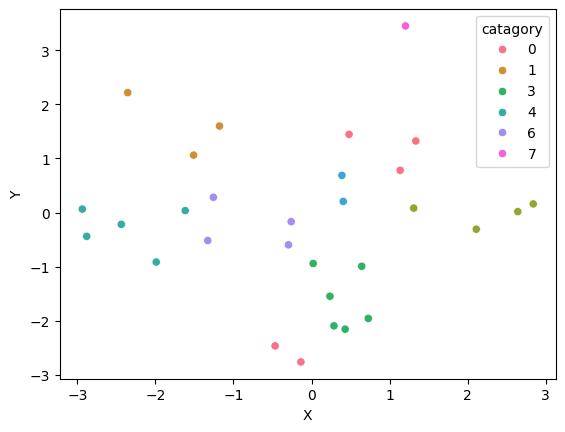

In [432]:
sns.scatterplot(df, x='X', y='Y', hue='catagory', legend='brief', palette='husl')

## Adding Transformers to the mix

In [433]:
from ollama import chat
from ollama import ChatResponse

In [434]:
catagories_unprocessed_labels = df.groupby('catagory')['label'].agg('; '.join)

In [435]:
processed_labels = []

def get_label_prediction(k):
    gen = ollama.generate(model='smollm2',
                    prompt=f'''Output the word or phrase which is most correlated with the following senquence of word: {k}''',
                    options={
                      'temperature': 0, # Makes it deterministic
                    })
    return gen['response']

In [462]:
processed_labels = catagories_unprocessed_labels.apply(get_label_prediction)
procd = processed_labels.str.extract(r'\"(.*)\"')
df['processed_labels'] = df['catagory'].apply(lambda a: procd.loc[a])

In [463]:
procd

,0
catagory,
0,car alarm
1,motorboat
2,alarm
3,speech
4,Tire squeal
5,idling
6,engine
7,Motorboat
8,large room


In [464]:
df

,X,Y,catagory,label,processed_labels
0,1.336193,1.322242,0,Vehicle; Reversing beeps; Squeal; Truck; Anima...,car alarm
1,-1.178361,1.598715,1,Vehicle; Engine; Sound effect; Motor vehicle (...,motorboat
2,2.642228,0.016636,2,"Speech; Radio; Outside, urban or manmade; Vehi...",alarm
3,0.236208,-1.547206,3,"Speech; Outside, urban or manmade; Inside, lar...",speech
4,0.287742,-2.095090,3,"Speech; Telephone; Inside, small room; Narrati...",speech
5,2.110316,-0.307875,2,"Speech; Inside, small room; Alarm; Buzzer; Ala...",alarm
6,-2.879106,-0.439554,4,Skidding; Vehicle; Motor vehicle (road); Speec...,Tire squeal
7,1.309452,0.081285,2,"Speech; Vehicle; Truck; Outside, urban or manm...",alarm
8,0.727360,-1.957845,3,"Speech; Outside, urban or manmade; Inside, lar...",speech
9,0.406555,0.205694,5,Speech; Engine; Motor vehicle (road); Vehicle;...,idling


<Axes: xlabel='X', ylabel='Y'>

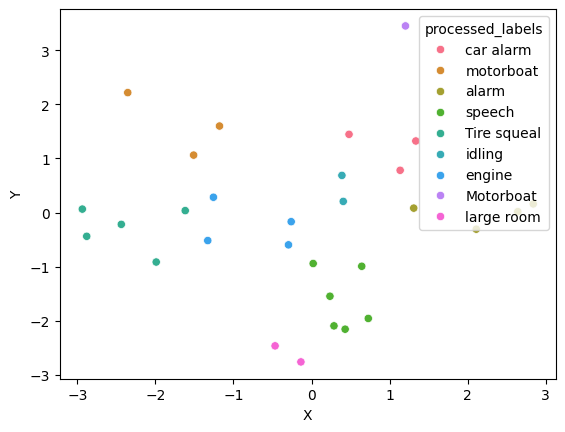

In [466]:
sns.scatterplot(df, x='X', y='Y', hue='processed_labels', legend='brief', palette='husl')